#CNN Cats!
Here we implement a Convolutional Neural Network illustrating how each layer processes and transforms the input image.

Here we import TensorFlow for CNN operations and Matplotlib for visualization.

Original Image Shape: (300, 300, 1)


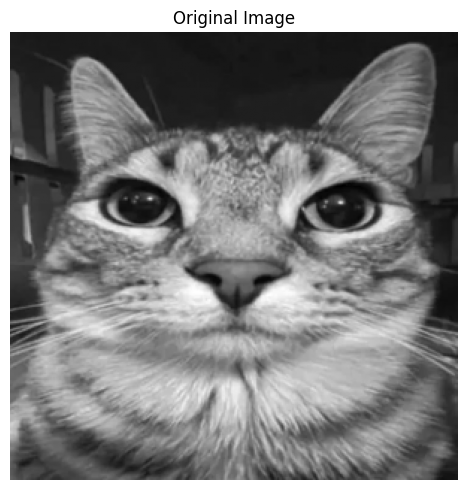

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

# Paste your copied path here
image_path = "/content/catcnn.jpg"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
# Since you loaded it as 1 channel (grayscale), squeeze removes the extra dimension for plotting
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension for your future CNN layers
image = tf.expand_dims(image, axis=0)

 ## Define Convolution Kernel
Define edge detection filter (Laplacian kernel) to extract importannt image features.

We see to it such that:

The Surrounding -1s: These look at the neighboring pixels.

The Center 8: This looks at the target pixel.

If the center pixel has the exact same brightness as all its neighbors, the math cancels out to zero: $$8(1) + 8(-1) = 0$$

This means that flat, solid areas will turn black, like the cat's forehead. Sharp contrast images, like the edge of the cats ears or whiskers, gives a high number, so the edge here will light up bright against the dark background.

In TensorFlow, a 2D convolutional kernel (tf.nn.conv2d) expects a 4D tensor formatted exactly like this:$$\text{[kernel_height, kernel_width, in_channels, out_channels]}$$

So how this maps: 3=height, vertical pixel size,

3=width, 3 pixels

1=In Channels, the number of channels in the input image. Since we loaded the cat image with channels=1(grayscale, channels=3 would be in colour RBG), so in_channels=1

1= Out Channels, the number of filters we are applying. Since we are only extracting 1 feature map (edges), 1

In [ ]:
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

## Apply Convolution Layer

The convolution layer applies the filter to the image to detect edges and features.




After Convolution Shape: (1, 300, 300, 1)


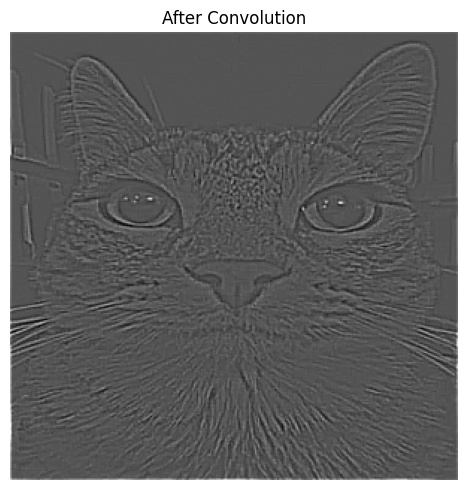

In [ ]:
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],  #filter slides 1 pixel at a time horizontally and vertically
    padding='SAME'  #adds a border of zero before sliding the edges, 300x300 output matches input
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

## Apply ReLU Activation Function
ReLU removes negative values and introduces non-linearity into the network.

The standard formula for ReLU (Rectified Linear Unit) is:$$\text{ReLU}(x) = \max(0, x)$$Negative Values $\rightarrow$ 0: Any pixel where the math resulted in a negative number (flat areas, gentle gradients, or inverse edges) is instantly clipped to exactly 0 (pure black).Positive Values $\rightarrow$ Kept: Any pixel where a strong edge was detected (positive values) passes through completely unchanged.

After ReLU Shape: (1, 300, 300, 1)


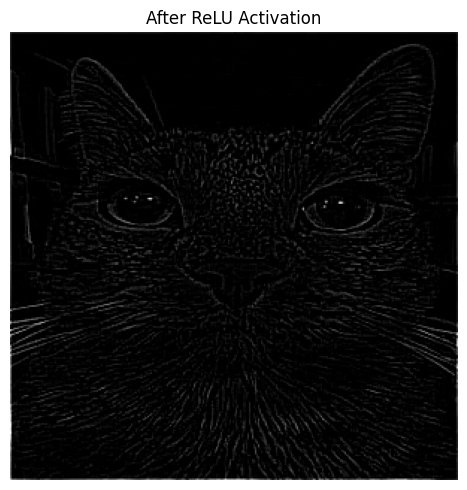

In [ ]:
relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

## Apply Max Pooling Layer
Max pooling reduces spatial dimensions while keeping important features.
ksize=[1, 2, 2, 1]: This sets the pool window size to $2 \times 2$

pixels.strides=[1, 2, 2, 1]: This tells the window to hop over by 2 pixels vertically and horizontally after each step, meaning the windows never overlap.

It takes the maximum value out of every $2 \times 2$ block, it keeps the brightest edge pixel it can find and discards the other 3. This gives your network translational invariance—meaning if the cat shifts a pixel or two to the left, the network will still see the exact same edge features.

The output "After Pooling Shape" reveals the dimensions have been cut in half:


After Pooling Shape: (1, 150, 150, 1)


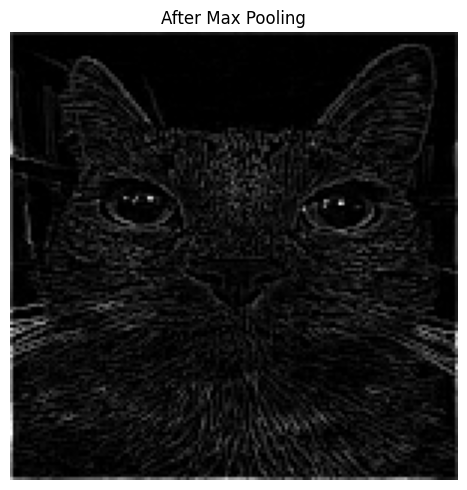

In [ ]:
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=[1, 2, 2, 1],
    strides=[1, 2, 2, 1],
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

## Apply Flatten Layer

The flatten layer converts 2D feature maps into a 1D feature vector for fully connected layers.




In [ ]:
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[1052.3726   659.1018   658.81433  623.0952   592.8568   590.1189
  589.6308   594.1206   605.647    620.45276  624.32776  607.0044
  561.39703  581.2208   626.2839   611.0176   587.8054   588.4285
  584.0783   577.31885]


## Add Fully Connected (Dense) Layer
The fully connected layer learns high-level patterns from the flattened feature vector and produces output predictions.


Every single one of the 64 neurons in this layer connected to every single one of the 22,500 input features.

Tensorflow performs the dot product:

$$\text{Input } (1 \times 22,500) \times \text{Weights } (22,500 \times 64) = \text{Output } (1 \times 64)$$

It then added a bias value to each of the 64 outputs.

: Finally, it ran those 64 numbers through another ReLU activation, turning any negative results into 0.

In [ ]:
dense_layer = tf.keras.layers.Dense(
    units=64,
    activation='relu'
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: (1, 64)
